# Travel Demand Forecasting Using SARIMA

## Business Problem

Forecasting travel demand is relevant for multiple industries, such as tourism, transportation, hospitality. Good forecasts help organizations figure out staffing, allocate resources, and prepare for seasonal swings.

In this project, I study whether historical travel data could be used to predict how many international trips Finnish citizens take each year. For analysis, I used the Box-Jenkins methodology and built a Seasonal Autoregressive Integrated Moving Average (SARIMA) model.

The goal is to understand the patterns in the data and get a sense of how well those patterns hold up for predicting future demand.

---

## Dataset

The data comes from Statistics Finland and tracks monthly counts of trips abroad taken by Finnish citizens.

The dataset was cut off at December 2019 to avoid the structural break from COVID-19.

**Dataset Information**

- Source: Statistics Finland
- Frequency: Monthly
- Time period: 2012–2019
- Target variable: Number of trips abroad (thousands)

---

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

---

## Load and Prepare Data

The dataset is loaded into a Pandas DataFrame and converted into a monthly time series. Setting the date column as the index allows us to use time-series methods and visualizations more effectively throughout the analysis.

In [9]:
df = pd.read_csv(
   "trips-abroad.txt",
   sep="\t",
   encoding="latin1"
)

df['Kuukausi'] = pd.to_datetime(df['Kuukausi'], format='%YM%m')
ts = (df.set_index('Kuukausi').asfreq("MS"))
y = ts['Ulkomaanmatkat'].rename('Trips')

print(y.index.min(), "→", y.index.max())
y.head()
y.describe()

2012-01-01 00:00:00 → 2019-12-01 00:00:00


count      96.000000
mean      843.437500
std       131.548095
min       490.000000
25%       770.000000
50%       845.000000
75%       920.000000
max      1160.000000
Name: Trips, dtype: float64

---

## Exploratory Data Analysis

Before selecting a forecasting model, it is important to understand the basic characteristics of the data.

In this step, I visualize the monthly travel volumes to identify trends, seasonal patterns, and unusual observations. Understanding these characteristics helps determine whether transformations or differencing will be needed later in the modeling process.

### Monthly Travel Volumes

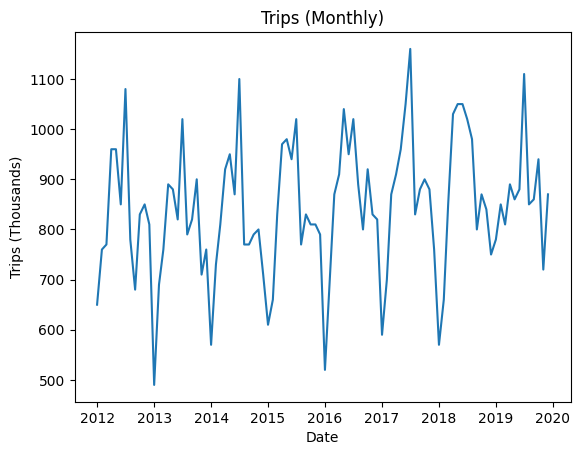

In [10]:
plt.figure()
plt.plot(y)
plt.title("Trips (Monthly)")
plt.xlabel("Date")
plt.ylabel("Trips (Thousands)")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.show()

### Interpretation

The time series shows two important characteristics:

1. **An upward trend** – travel volumes gradually increase over time, indicating that the average level of the series is changing.
2. **Strong annual seasonality** – travel volumes consistently peak during summer months and decline during winter months.

These patterns suggest that the series is not stationary. Since many forecasting models, including ARIMA-based models, assume stationarity, we will likely need to remove both the trend and seasonal components before model estimation.

The clear seasonal pattern also suggests that a seasonal forecasting model may be appropriate.

---

## Model Identification

The Box-Jenkins methodology begins with identifying an appropriate model structure.

To determine how much differencing is required and whether autoregressive (AR) or moving average (MA) components should be included, I examine the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF).

These plots help reveal relationships between observations across different time lags.

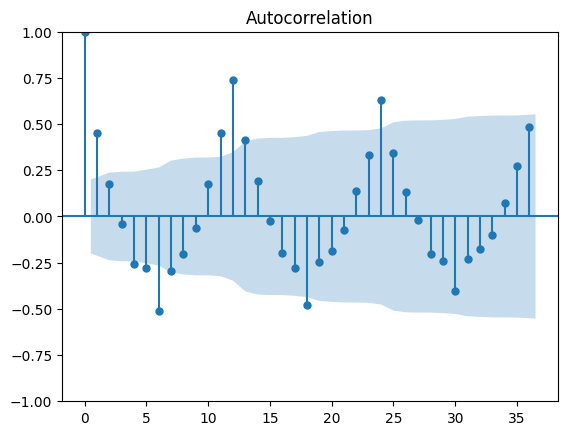

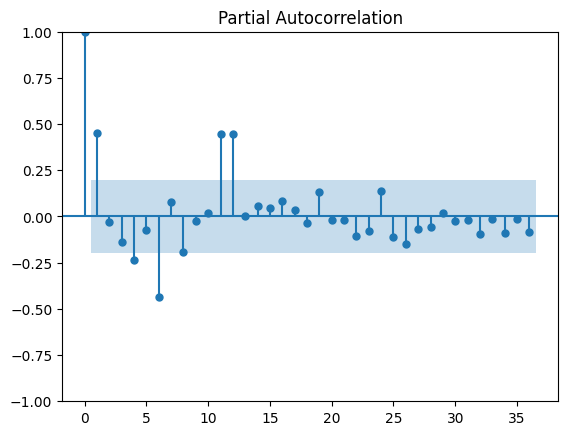

In [11]:
plot_acf(y, lags=36)
plt.show()

plot_pacf(y, lags=36, method="ywm")
plt.show()

### Interpretation

The ACF displays a slow decay rather than an immediate drop toward zero. This behavior is commonly associated with non-stationary data and suggests that the series contains a trend.

In addition, large spikes appear at lags 12, 24, and 36. Since the data is monthly, these lags correspond to one-year intervals and indicate a strong seasonal component.

The PACF also shows significant spikes at early lags and around lag 12, providing further evidence that both trend and seasonality are present.

Because the series appears non-stationary, differencing is required before a forecasting model can be estimated.

---

## First-Order Differencing

First-order differencing removes changes in the overall level of the series by calculating the difference between consecutive observations.

This step is commonly used to eliminate long-term trends and create a stationary series.

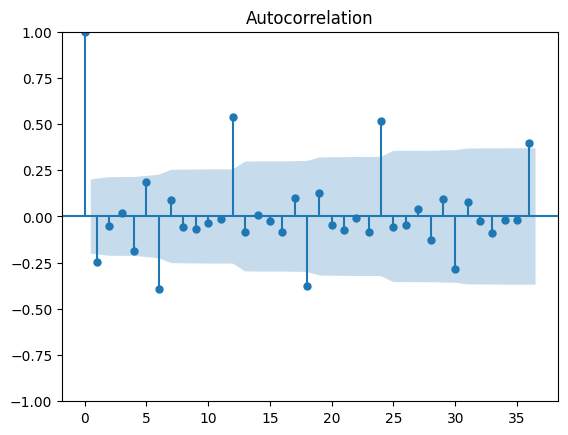

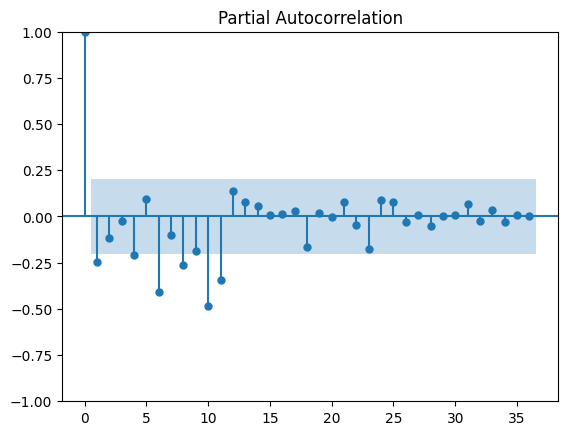

In [12]:
y_diff1 = y.diff().dropna()

plot_acf(y_diff1, lags=36)
plt.show()

plot_pacf(y_diff1, lags=36, method="ywm")
plt.show()

### Interpretation

After first-order differencing, the slow decay observed in the original ACF disappears. This indicates that the trend component has been successfully removed.

However, strong spikes remain at seasonal lags such as 12 and 24 months. This suggests that although the trend has been eliminated, seasonal dependence is still present.

The series therefore requires seasonal differencing in addition to first-order differencing.

---

## Seasonal Differencing

Seasonal differencing removes repeating yearly patterns by subtracting each observation from the corresponding observation one year earlier.

For monthly data, a lag of 12 months is used.

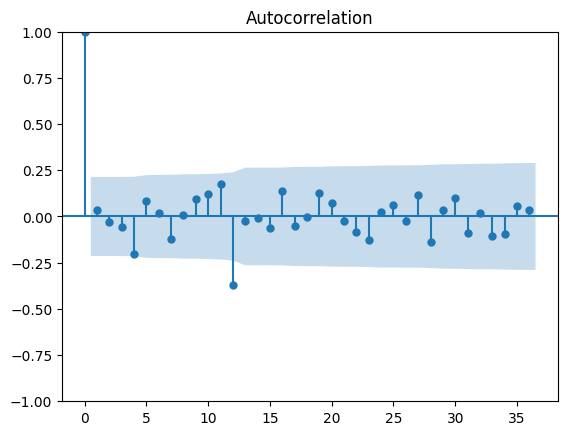

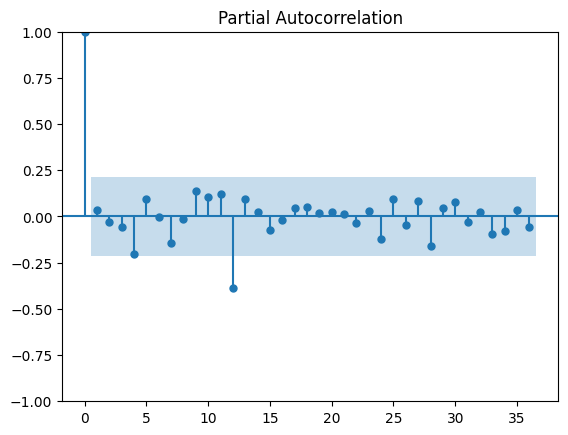

In [13]:
y_seasdiff = y.diff(12).dropna()

plot_acf(y_seasdiff, lags=36)
plt.show()

plot_pacf(y_seasdiff, lags=36, method="ywm")
plt.show()

### Interpretation

The seasonal spikes observed in earlier ACF plots are greatly reduced after seasonal differencing.

This indicates that the yearly seasonal pattern has largely been removed from the series.

The strong negative spike at lag 12 suggests that a seasonal moving average component may help capture the remaining seasonal structure.

Based on these observations, a SARIMA model with both regular and seasonal differencing appears appropriate.

---

## Train-Test Split

To evaluate forecasting performance, the final 12 months of observations are held out as a test set.

The model is trained using earlier observations and then used to predict future values that were not seen during training.

This approach provides a realistic assessment of forecasting accuracy.

In [14]:
y_log = np.log(y)

h = 12

train = y_log.iloc[:-h]
test = y_log.iloc[-h:]

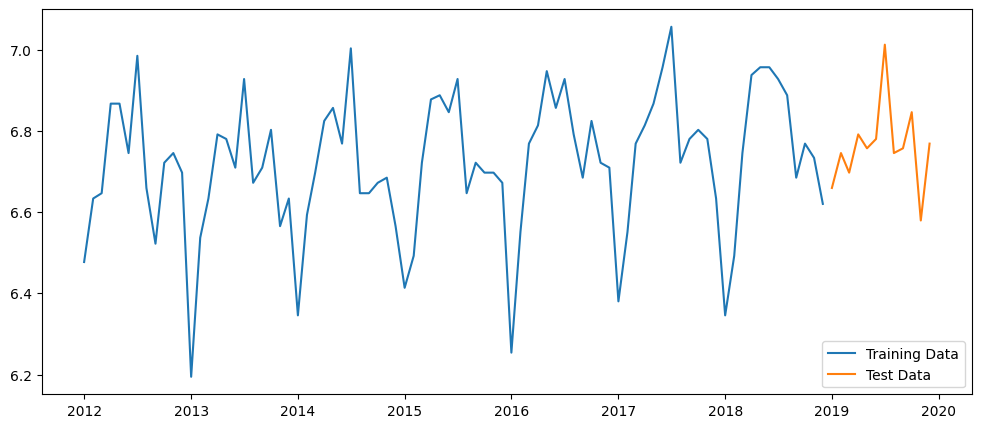

In [15]:
plt.figure(figsize=(12,5))

plt.plot(train, label="Training Data")
plt.plot(test, label="Test Data")

plt.legend()
plt.show()

### Interpretation

The training period contains historical observations used for model estimation, while the test period serves as an out-of-sample evaluation set.

Separating the data in this way allows forecast performance to be measured on observations that were not used during model fitting, reducing the risk of overly optimistic results.

---

## Model Estimation

Based on the identification stage, the following model is selected:

SARIMA(0,1,0)(0,1,1)₁₂

This specification includes:

- First-order differencing to remove trend
- Seasonal differencing to remove annual seasonality
- A seasonal moving average component to capture remaining seasonal dependence

The model is estimated using the SARIMAX framework in Python.

In [16]:
model = sm.tsa.SARIMAX(
    train,
    order=(0,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit()

print(res.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Trips   No. Observations:                   84
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                  51.428
Date:                              Fri, 19 Jun 2026   AIC                            -98.855
Time:                                      14:33:15   BIC                            -94.734
Sample:                                  01-01-2012   HQIC                           -97.250
                                       - 12-01-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.6337      0.176     -3.604      0.000      -0.978      -0.289
sigma2         0.00

### Interpretation

The estimated seasonal moving average coefficient is statistically significant, suggesting that seasonal dependencies remain important even after differencing.

Model selection is ultimately validated through residual diagnostics rather than coefficient significance alone, so the next step is to examine whether the residuals resemble white noise.

---

## Residual Diagnostics

A good forecasting model should leave no systematic patterns unexplained.

Residuals should:

- Be centered around zero
- Have approximately constant variance
- Show no significant autocorrelation
- Follow a roughly normal distribution

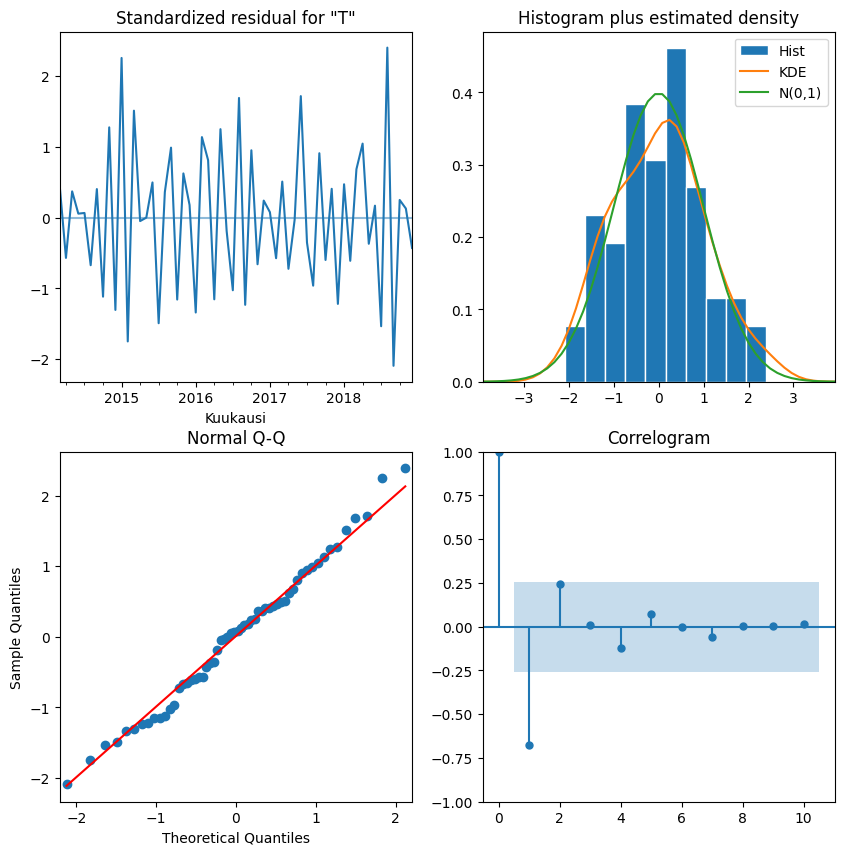

In [17]:
res.plot_diagnostics(figsize=(10,10))
plt.show()

In [18]:
lb = acorr_ljungbox(
    res.resid.dropna(),
    lags=[12,24],
    return_df=True
)

lb

,lb_stat,lb_pvalue
12,24.108235,0.019662
24,24.393677,0.439280


### Interpretation

The residual plots indicate that most of the systematic structure in the data has been captured by the model.

The residuals fluctuate around zero without obvious trends or seasonal patterns. While some short-term autocorrelation remains, overall model performance appears acceptable for forecasting purposes.

The Ljung-Box test suggests that residual autocorrelation weakens substantially at longer lags, indicating that the model captures most of the temporal dependence present in the series.

---

## Forecasting

The fitted model is used to generate forecasts for the 12-month test period.

Forecasts are transformed back to the original scale and compared with the actual observations.

In [19]:
fc = res.get_forecast(steps=h)

fc_mean = np.exp(fc.predicted_mean)
fc_ci = np.exp(fc.conf_int())

y_test_orig = np.exp(test)
y_train_orig = np.exp(train)

---

## Forecast Accuracy

Forecast accuracy is evaluated using three commonly used metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

In [20]:
mae = mean_absolute_error(y_test_orig, fc_mean)
rmse = np.sqrt(mean_squared_error(y_test_orig, fc_mean))
mape = np.mean(
    np.abs((y_test_orig - fc_mean) / y_test_orig)
) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 94.27
RMSE: 114.91
MAPE: 11.04%


### Interpretation

The model achieves a Mean Absolute Percentage Error (MAPE) of approximately 11%, meaning that forecasts differ from actual observations by roughly 11% on average.

The forecasts successfully capture the recurring seasonal pattern, although uncertainty increases further into the forecast horizon.

For a univariate model using only historical travel volumes, this level of accuracy demonstrates that seasonal patterns provide useful predictive information.

---

## Forecast Visualization

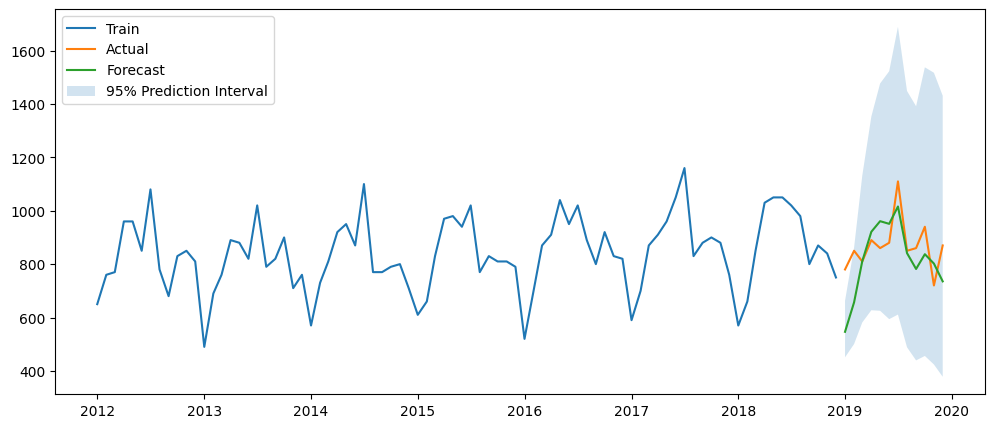

In [21]:
plt.figure(figsize=(12,5))

plt.plot(y_train_orig, label="Train")
plt.plot(y_test_orig, label="Actual")
plt.plot(fc_mean, label="Forecast")

plt.fill_between(
    fc_mean.index,
    fc_ci.iloc[:,0],
    fc_ci.iloc[:,1],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.legend()
plt.show()

### Interpretation

The forecast follows the overall seasonal pattern observed in the historical data, predicting higher travel volumes during summer months and lower volumes during winter months.

The prediction intervals widen over time, reflecting increasing uncertainty as forecasts extend further into the future.

Most actual observations fall within the forecast intervals, suggesting that the model provides reasonable estimates despite some forecast error.

---

## Conclusions

This project demonstrates how the Box-Jenkins methodology can be applied to forecast travel demand using a SARIMA model.

Key findings include:

- Monthly travel volumes exhibit strong annual seasonality.
- First-order and seasonal differencing successfully remove non-stationarity.
- A SARIMA model captures the majority of recurring travel patterns.
- Forecasts achieve approximately 11% average error.
- Additional explanatory variables could further improve forecasting performance.

Future work could compare SARIMA with alternative forecasting approaches such as Prophet, Exponential Smoothing, or SARIMAX models incorporating external variables.